In [6]:
%matplotlib inline

from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from numpy.random import seed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


In [ ]:
# Import data

data_path = Path("../../data/mock/new/data.csv")
df = pd.read_csv(data_path)

display(df.head())
print(f"Rows and columns: {df.shape}")
print("\nRatings:")
display(df["rating"].value_counts().sort_index().rename("rows_per_rating"))

display(df.describe().round(2))


,max30minTemp,min30minTemp,mean30minTemp,trend30minTemp,std30minTemp,max30minHumidity,min30minHumidity,mean30minHumidity,trend30minHumidity,std30minHumidity,...,min30minLight,mean30minLight,trend30minLight,std30minLight,max30minCO2,min30minCO2,mean30minCO2,trend30minCO2,std30minCO2,rating
0,23.718,23.7,23.709000,0.000000,0.012728,26.29,26.272,26.28100,0.000000,0.012728,...,578.400000,581.800000,0.000000,4.808326,760.400000,749.2,754.800000,0.000000,7.919596,5
1,23.730,23.7,23.716000,0.010500,0.015100,26.29,26.230,26.26400,-0.025500,0.030790,...,572.666667,578.755556,-4.566667,6.274227,769.666667,749.2,759.755556,7.433333,10.248541,4
2,23.730,23.7,23.717625,0.005833,0.012750,26.29,26.125,26.22925,-0.046111,0.073907,...,493.750000,557.504167,-23.842593,42.810397,774.750000,749.2,763.504167,6.824074,11.235216,4
3,23.754,23.7,23.724900,0.009328,0.019661,26.29,26.125,26.22340,-0.029344,0.065328,...,488.600000,543.723333,-24.416146,48.208966,779.000000,749.2,766.603333,6.261979,11.945573,4
4,23.760,23.7,23.730750,0.010916,0.022684,26.29,26.125,26.22950,-0.018327,0.060312,...,488.600000,547.880556,-15.849340,44.305513,790.000000,749.2,770.502778,7.309736,14.331482,4


Rows and columns: (2664, 21)

Ratings:


rating
2       8
3    1416
4    1174
5      66
Name: rows_per_rating, dtype: int64

,max30minTemp,min30minTemp,mean30minTemp,trend30minTemp,std30minTemp,max30minHumidity,min30minHumidity,mean30minHumidity,trend30minHumidity,std30minHumidity,...,min30minLight,mean30minLight,trend30minLight,std30minLight,max30minCO2,min30minCO2,mean30minCO2,trend30minCO2,std30minCO2,rating
count,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,...,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00,2664.00
mean,21.52,21.34,21.43,0.00,0.05,25.59,25.13,25.36,0.00,0.14,...,169.46,191.66,0.03,17.99,743.97,688.28,715.92,0.19,16.49,3.49
std,1.06,0.98,1.02,0.01,0.06,2.54,2.33,2.43,0.02,0.14,...,228.01,241.90,4.33,50.10,306.17,274.54,290.17,2.53,16.06,0.55
min,20.29,20.20,20.23,-0.02,0.00,22.20,22.10,22.14,-0.08,0.00,...,0.00,0.00,-24.42,0.00,438.75,427.50,433.69,-6.34,1.90,2.00
25%,20.70,20.60,20.65,-0.00,0.02,23.39,23.10,23.26,-0.01,0.04,...,0.00,0.00,0.00,0.00,473.25,457.40,465.40,-0.94,3.49,3.00
50%,21.00,20.89,20.91,-0.00,0.04,25.12,24.86,24.97,-0.00,0.09,...,0.00,0.00,0.00,0.00,605.67,561.37,579.42,-0.14,9.64,3.00
75%,22.55,22.18,22.34,0.00,0.07,27.39,26.39,26.85,0.00,0.18,...,429.00,441.57,0.00,7.84,1014.10,892.33,952.69,0.47,26.19,4.00
max,24.41,23.79,24.13,0.04,0.36,31.47,31.20,31.31,0.08,0.71,...,755.50,785.75,21.19,268.29,1402.25,1368.80,1390.14,8.08,70.66,5.00


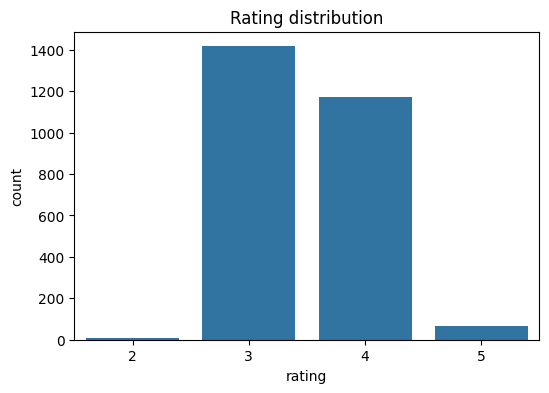

mean30minLight        0.633
min30minLight         0.584
max30minLight         0.566
min30minTemp          0.484
mean30minTemp         0.482
max30minCO2           0.478
max30minTemp          0.477
mean30minCO2          0.466
min30minCO2           0.451
std30minHumidity      0.440
std30minCO2           0.434
max30minHumidity      0.402
mean30minHumidity     0.377
min30minHumidity      0.351
std30minLight         0.258
trend30minCO2         0.225
trend30minTemp        0.208
trend30minHumidity    0.169
std30minTemp          0.145
trend30minLight       0.029
Name: correlation_with_rating, dtype: float64

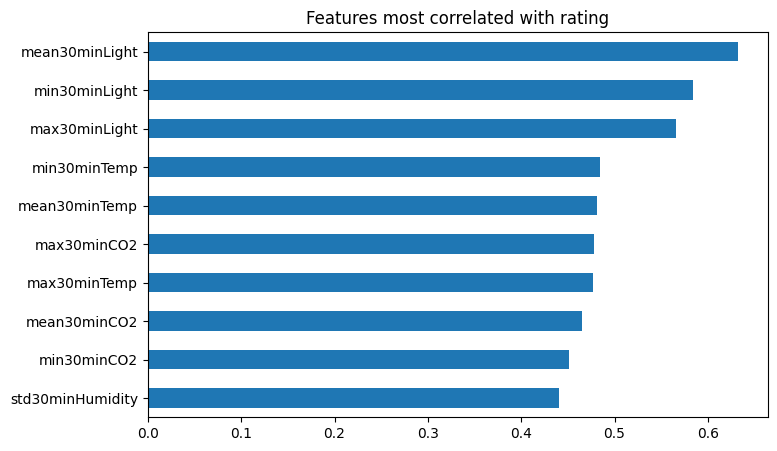

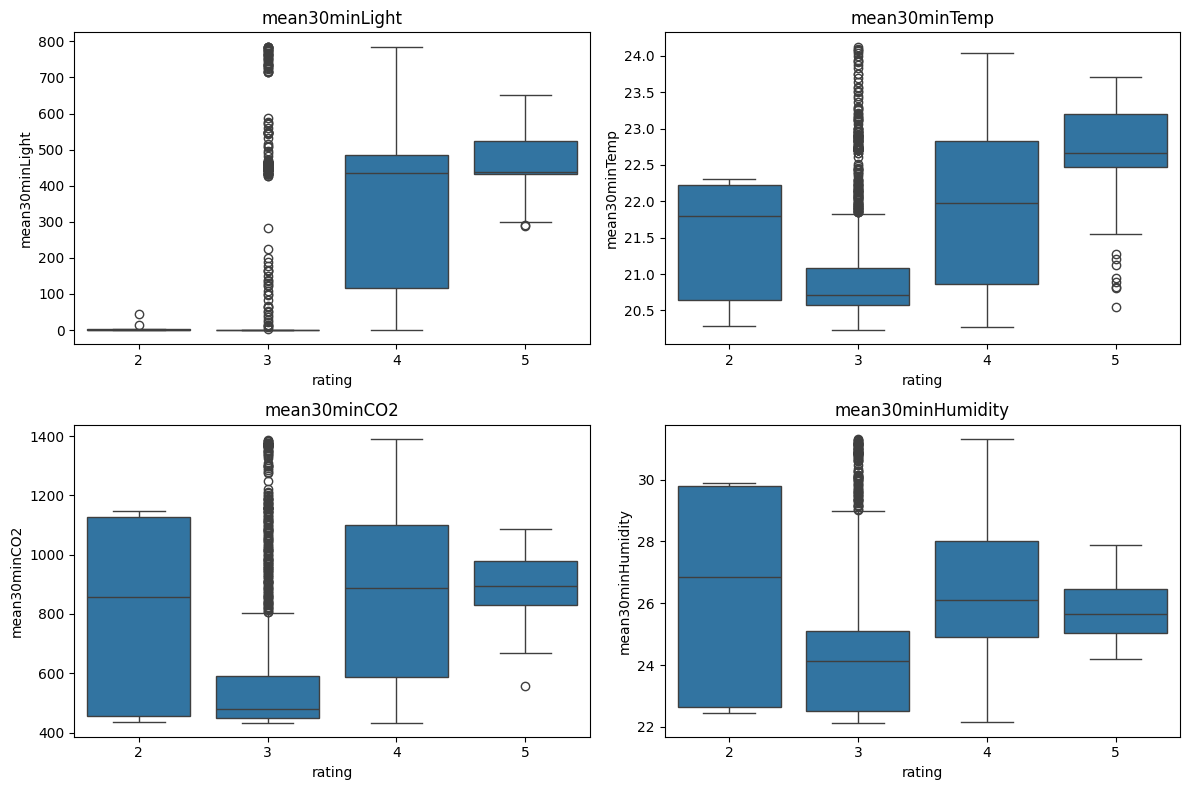

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="rating", order=sorted(df["rating"].unique()))
plt.title("Rating distribution")
plt.show()

corr = df.corr(numeric_only=True)["rating"].drop("rating")
corr = corr.sort_values(key=lambda x: x.abs(), ascending=False)

display(corr.round(3).rename("correlation_with_rating"))

plt.figure(figsize=(8, 5))
corr.head(10).sort_values().plot(kind="barh")
plt.title("Features most correlated with rating")
plt.show()

important_features = ["mean30minLight", "mean30minTemp", "mean30minCO2", "mean30minHumidity"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feature in zip(axes.flatten(), important_features):
    sns.boxplot(data=df, x="rating", y=feature, ax=ax)
    ax.set_title(feature)

plt.tight_layout()
plt.show()


In [9]:
# Split, scale, encode

TARGET_COLUMN = "rating"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

rating_values = sorted(y.unique())
rating_to_index = {rating: index for index, rating in enumerate(rating_values)}
index_to_rating = {index: rating for rating, index in rating_to_index.items()}
num_classes = len(rating_values)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train_index = y_train.map(rating_to_index).to_numpy()
y_val_index = y_val.map(rating_to_index).to_numpy()
y_test_index = y_test.map(rating_to_index).to_numpy()

Y_train = to_categorical(y_train_index, num_classes)
Y_val = to_categorical(y_val_index, num_classes)
Y_test = to_categorical(y_test_index, num_classes)

input_size = X_train_scaled.shape[1]

display(pd.DataFrame({
    "train": y_train.value_counts().sort_index(),
    "validation": y_val.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index()
}).fillna(0))


,train,validation,test
rating,,,
2,5,1,2
3,906,227,283
4,751,188,235
5,42,11,13


In [10]:
# Helper functions

def reset_seeds():
    seed(0)
    random.seed(0)
    tf.random.set_seed(0)

def build_model(hidden_layers, optimizer_name="sgd", learning_rate=0.05, dropout=0):
    reset_seeds()
    
    model = Sequential()
    model.add(Input(shape=(input_size,)))
    
    for units in hidden_layers:
        model.add(Dense(units=units, activation="relu"))
        if dropout > 0:
            model.add(Dropout(dropout))
            
    model.add(Dense(units=num_classes, activation="softmax"))
    
    if optimizer_name == "sgd":
        optimizer = SGD(learning_rate=learning_rate)
    else:
        optimizer = Adam(learning_rate=learning_rate)
        
    model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

def decode_predictions(probabilities):
    prediction_indexes = np.argmax(probabilities, axis=1)
    return np.array([index_to_rating[index] for index in prediction_indexes])

def evaluate_model(name, model, history):
    val_predictions = decode_predictions(model.predict(X_val_scaled, verbose=0))
    test_predictions = decode_predictions(model.predict(X_test_scaled, verbose=0))
    
    return {
        "model": name,
        "val_accuracy": accuracy_score(y_val, val_predictions),
        "val_macro_f1": f1_score(y_val, val_predictions, average="macro"),
        "test_accuracy": accuracy_score(y_test, test_predictions),
        "test_macro_f1": f1_score(y_test, test_predictions, average="macro"),
        "epochs": len(history.history["loss"])
    }


In [11]:
# Train experiments

results = []
trained_models = {}
histories = {}

majority_rating = y_train.mode()[0]
majority_predictions = np.repeat(majority_rating, len(y_test))

results.append({
    "model": "always predict most common rating",
    "val_accuracy": None,
    "val_macro_f1": None,
    "test_accuracy": accuracy_score(y_test, majority_predictions),
    "test_macro_f1": f1_score(y_test, majority_predictions, average="macro"),
    "epochs": 0
})

experiments = {
    "simple NN with SGD": build_model((32,), "sgd", 0.05),
    "simple NN with Adam": build_model((32,), "adam", 0.001),
    "larger NN with dropout": build_model((64, 32), "adam", 0.001, dropout=0.2)
}

for name, model in experiments.items():
    history = model.fit(
        X_train_scaled, Y_train,
        epochs=60,
        batch_size=50,
        validation_data=(X_val_scaled, Y_val),
        verbose=0,
        callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)]
    )
    
    trained_models[name] = model
    histories[name] = history
    results.append(evaluate_model(name, model, history))

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train_index
)

class_weights = {index: weight for index, weight in enumerate(class_weights_array)}

weighted_model = build_model((64, 32), "adam", 0.001, dropout=0.2)
weighted_history = weighted_model.fit(
    X_train_scaled, Y_train,
    epochs=60,
    batch_size=50,
    validation_data=(X_val_scaled, Y_val),
    verbose=0,
    callbacks=[EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    class_weight=class_weights
)

trained_models["weighted NN"] = weighted_model
histories["weighted NN"] = weighted_history
results.append(evaluate_model("weighted NN", weighted_model, weighted_history))

results_df = pd.DataFrame(results)
display(results_df.round(3))


,model,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,epochs
0,always predict most common rating,NaN,NaN,0.531,0.173,0
1,simple NN with SGD,0.838,0.423,0.801,0.403,60
2,simple NN with Adam,0.829,0.418,0.803,0.403,60
3,larger NN with dropout,0.831,0.419,0.803,0.403,40
4,weighted NN,0.724,0.440,0.702,0.451,25


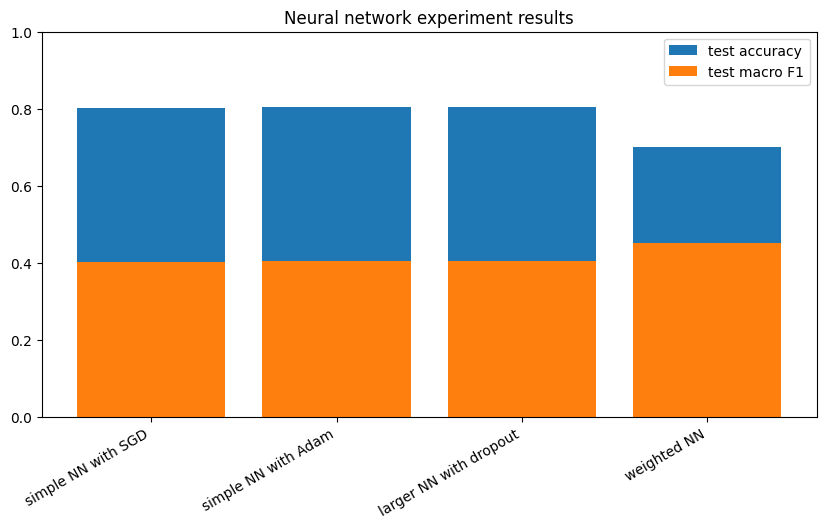

In [12]:
# Results

plot_df = results_df.dropna()

plt.figure(figsize=(10, 5))
plt.bar(plot_df["model"], plot_df["test_accuracy"], label="test accuracy")
plt.bar(plot_df["model"], plot_df["test_macro_f1"], label="test macro F1")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Neural network experiment results")
plt.legend()
plt.show()


Best model based on validation macro F1: weighted NN
              precision    recall  f1-score   support

           2       0.08      0.50      0.14         2
           3       0.80      0.87      0.83       283
           4       0.79      0.50      0.61       235
           5       0.13      0.62      0.22        13

    accuracy                           0.70       533
   macro avg       0.45      0.62      0.45       533
weighted avg       0.77      0.70      0.72       533



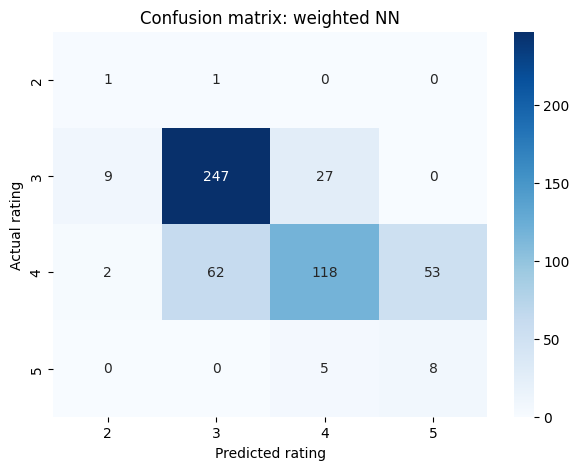

,max30minTemp,min30minTemp,mean30minTemp,trend30minTemp,std30minTemp,max30minHumidity,min30minHumidity,mean30minHumidity,trend30minHumidity,std30minHumidity,...,mean30minLight,trend30minLight,std30minLight,max30minCO2,min30minCO2,mean30minCO2,trend30minCO2,std30minCO2,actual_rating,predicted_rating
2542,21.000000,20.8400,20.920764,6.635143e-03,6.231540e-02,25.4120,25.050000,25.312121,0.003044,0.089115,...,439.707471,0.889376,9.295189,721.400000,623.750000,684.069540,3.338589,30.054676,4,5
2012,20.917500,20.8650,20.891855,-5.728615e-04,9.638632e-03,25.1600,24.917500,25.036989,-0.006089,0.060386,...,0.000000,0.000000,0.000000,563.400000,548.500000,556.899462,-0.153751,3.364349,4,3
349,21.200000,21.1000,21.119444,-2.585930e-03,3.364320e-02,23.7900,23.392500,23.571444,-0.009834,0.097336,...,0.000000,0.000000,0.000000,567.333333,524.500000,546.821111,-1.221373,11.476256,4,3
1569,22.890000,22.7450,22.817081,-4.482920e-03,4.769558e-02,31.1500,30.810000,30.929918,0.009107,0.098094,...,445.573733,-0.256235,3.948952,1388.600000,1353.750000,1368.054455,-0.530251,8.273293,3,4
1824,21.200000,21.1600,21.197556,-4.529898e-04,9.343727e-03,27.2900,26.790000,27.044806,-0.019158,0.170585,...,0.000000,0.000000,0.000000,738.250000,677.666667,704.118333,-1.781591,16.213937,3,4
2203,20.700000,20.7000,20.700000,-1.865108e-16,9.080967e-08,25.0000,24.790000,24.963500,-0.005384,0.061574,...,0.000000,0.000000,0.000000,499.000000,478.750000,489.103333,-0.464785,5.881093,4,3
2547,21.116667,20.8400,20.950683,8.315639e-03,7.719583e-02,25.4120,25.197500,25.312967,-0.004703,0.077651,...,443.628889,0.916735,9.482751,728.666667,649.500000,696.573333,2.548553,24.599681,5,4
2509,20.790000,20.4725,20.639545,1.123421e-02,1.012665e-01,25.0000,23.767500,24.369361,0.044861,0.408538,...,412.518889,-0.213475,7.564662,611.250000,473.750000,540.288651,4.559850,40.940568,4,5
1345,22.790000,22.3900,22.557439,1.609795e-02,1.448539e-01,27.2900,26.516667,26.891300,-0.028465,0.254364,...,632.386111,2.608141,28.164367,1065.250000,1014.166667,1036.866111,-1.614949,15.307364,5,4
2306,20.700000,20.7000,20.700000,-1.732450e-17,9.080967e-08,24.6000,24.500000,24.522278,-0.002629,0.037602,...,0.000000,0.000000,0.000000,478.000000,461.333333,470.081111,-0.261228,3.893702,4,3


In [13]:
# Best model details

best_name = results_df.dropna().sort_values("val_macro_f1", ascending=False).iloc[0]["model"]
best_model = trained_models[best_name]

print(f"Best model based on validation macro F1: {best_name}")

test_probabilities = best_model.predict(X_test_scaled, verbose=0)
test_predictions = decode_predictions(test_probabilities)

print(classification_report(y_test, test_predictions, labels=rating_values, zero_division=0))

cm = confusion_matrix(y_test, test_predictions, labels=rating_values)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rating_values, yticklabels=rating_values)
plt.xlabel("Predicted rating")
plt.ylabel("Actual rating")
plt.title(f"Confusion matrix: {best_name}")
plt.show()

errors = X_test.copy()
errors["actual_rating"] = y_test.values
errors["predicted_rating"] = test_predictions
display(errors[errors["actual_rating"] != errors["predicted_rating"]].head(15))


## Conclusion

The neural network is viable, but only partly.

It performs much better than always predicting the most common rating. In my run, the simple neural network reached around 80% test accuracy, while the majority baseline was around 53%.

However, the dataset is very imbalanced. Ratings 3 and 4 dominate the data, while rating 2 and 5 have very few rows. Because of that, normal accuracy looks better than the model really is. Macro F1 is more honest here.

The weighted neural network is interesting because it gives more attention to rare classes. It usually lowers accuracy, but improves macro F1 and detects rating 2 and 5 better.

For SEP, neural networks can be tested, but they are probably not the best final model yet. The dataset is small and imbalanced, so simpler models may be easier to explain and maintain. A neural network becomes more relevant if we collect more real and balanced data.
